
# $\color{green}{\text{CUSTOMER SHOPPING BEHAVIOUR ANALYSIS}}$



## $\color{blue}{\text{Project Objective}}$


*DOMAIN: Retail & Sale*

The primary objective of this project is to analyze customer shopping behavior and demographic trends to identify the key drivers of sales and customer loyalty. By examining variables such as purchase history, seasonal preferences, and the effectiveness of promotional incentives, the study aims to provide actionable insights for optimizing inventory management, tailoring marketing strategies, and improving overall customer satisfaction

## $\color{blue}{\text{Problem Statement}}$
A leading retail company wants to better understand its customers' shopping behavior in order to improve sales, customer satisfaction, and long-term loyalty. The management team has noticed changes in purchasing patterns across demographics, product categories, and sales channels (online vs. offline). They are particularly interested in uncovering which factors, such as discounts, reviews, seasons, or payment preferences, drive consumer decisions and repeat purchases.
You are tasked with analyzing the company's consumer behavior dataset to answer the following overarching business question:
"How can the company leverage consumer shopping data to identify trends, improve customer engagement, and optimize marketing and product strategies?"

Dataset Link : https://drive.google.com/file/d/1O_Iu9flslaE-RA9aX_ttjTC8By7EUfdf/view?usp=drive_link

## $\color{blue}{\text{Dataset Overview}}$
This dataset comprises 3,950 consumer transaction records detailing customer demographics, purchasing habits, and marketing interactions. It tracks key metrics such as age, gender, and location alongside product specifics like category, price, and seasonal timing. Additionally, the data captures behavioral elements including subscription status, review ratings, and the use of promotional codes. While comprehensive, the dataset requires pre-processing to address missing values and inconsistencies in categorization, making it an ideal candidate for exploratory data analysis and predictive modeling

## $\color{red}{\text{1.Initial Data Loading and Structural Inspection}}$
 This section initializes the analysis by importing the necessary Python libraries and loading the raw shopping behavior dataset from Google Drive. The preliminary check includes retrieving the dimensions of the data (rows and columns) and displaying the first few records to verify that the headers and data types have loaded correctly.

## 1.1 Imported Libraries

In [53]:
#Imported the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Data Loading and the Primary Overview

In [54]:

# Load the file
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1O_Iu9flslaE-RA9aX_ttjTC8By7EUfdf')

# Total no:of columns and Rows in the dataset
print("Total no:of rows and columns are ",df.shape)
# View the first 5 rows
df.head()

Total no:of rows and columns are  (3950, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55.0,Male,Blouse,clothin,53.0,NaN,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14.0,Venmo,Fortnightly
1,2,19.0,Male,Sweater,clothin,64.0,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2.0,Cash,Fortnightly
2,3,50.0,Male,Jeans,clothin,73.0,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23.0,CC,Weekly
3,4,21.0,NaN,Sandals,Foot-wear,NaN,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49.0,pay pal,Weekly
4,5,45.0,male,Blouse,NaN,49.0,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31.0,pay pal,Annually


**Summary**

1.**Loads the Dataset**: It reads the customer shopping behaviour data from the specified link into a pandas DataFrame named df.

2.**Displays Dataset Dimensions**: It prints the total number of rows and columns in the DataFrame, giving a quick understanding of its size.This dataset consists of **3950 rows and 18 columns**.

3.**Shows First Rows**: It displays the first 5 rows of the DataFrame, allowing for a preliminary check of the data's structure, column headers, and initial values.


## $\color{red}{\text{2. Data Quality Assessment and Cleaning Identification}}$
Before performing any analysis, it is essential to evaluate the "health" of the dataset. This code block identifies missing data, detects duplicate records, and highlights inconsistencies in categorical labels (such as mismatched naming conventions). It also uses descriptive statistics to spot "impossible" values, such as negative prices or unrealistic ages, ensuring the data is accurate and reliable for future steps

In [55]:
#Identifying the Metadata to check the data types and count of null values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3950 entries, 0 to 3949
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3950 non-null   int64  
 1   Age                     3752 non-null   float64
 2   Gender                  3752 non-null   object 
 3   Item Purchased          3950 non-null   object 
 4   Category                3752 non-null   object 
 5   Purchase Amount (USD)   3754 non-null   float64
 6   Location                3752 non-null   object 
 7   Size                    3950 non-null   object 
 8   Color                   3950 non-null   object 
 9   Season                  3950 non-null   object 
 10  Review Rating           3913 non-null   float64
 11  Subscription Status     3950 non-null   object 
 12  Shipping Type           3950 non-null   object 
 13  Discount Applied        3950 non-null   object 
 14  Promo Code Used         3950 non-null   

In [56]:
# Check for missing values
print("Missing Values per Column:\n", df.isnull().sum())


Missing Values per Column:
 Customer ID                 0
Age                       198
Gender                    198
Item Purchased              0
Category                  198
Purchase Amount (USD)     196
Location                  198
Size                        0
Color                       0
Season                      0
Review Rating              37
Subscription Status         0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases        198
Payment Method              0
Frequency of Purchases      0
dtype: int64


**Missing Values**: Several important columns, including Age, Gender, Category, Purchase Amount (USD), Location, Review Rating, and Previous Purchases, contain missing values.

In [57]:
# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 9


**Duplicate Rows**: The dataset contains 9 duplicate rows.

In [58]:
# Check for inconsistent categorical values
print("\nUnique Gender values:", df['Gender'].unique())
print("Unique Category values:", df['Category'].unique())


Unique Gender values: ['Male' nan 'male' 'M' 'Female' 'female' 'F']
Unique Category values: ['clothin' 'Foot-wear' nan 'Outerwear' 'Accessories']


**Categorical Inconsistencies**: The Gender and Category columns have inconsistent entries (e.g., 'Male', 'male', 'M' for gender; 'clothin' for clothing).

In [59]:
# Check for impossible numerical values (Outliers)
print("\nNumerical Statistics:")
print(df[['Age', 'Purchase Amount (USD)', 'Review Rating']].describe())


Numerical Statistics:
               Age  Purchase Amount (USD)  Review Rating
count  3752.000000            3754.000000    3913.000000
mean     44.294243              59.196590       3.750677
std      17.200847              25.627624       0.717749
min       0.000000             -99.000000       2.500000
25%      31.000000              39.000000       3.100000
50%      44.000000              60.000000       3.800000
75%      57.000000              81.000000       4.400000
max     195.000000             100.000000       5.000000


**Impossible Numerical Values**: The Age column contains values like 0 and 195, which are unrealistic, and the Purchase Amount (USD) column has negative values, which are logically impossible.

## $\color{red}{\text{3. Data Cleaning and Consistency Standardization}}$
This stage focus on ensuring data integrity by removing duplicate records and rectifying inconsistencies in categorical variables. It standardizes the 'Gender' and 'Category' fields for uniform analysis and cleans up geographical strings by removing leading or trailing spaces. Furthermore, it identifies and isolates logically impossible numerical values—such as unrealistic ages or negative purchase amounts—by marking them as "Not a Number" ($NaN$). This preparation is crucial to prevent skewed results and ensure the reliability of the subsequent statistical analysis.

In [60]:
# 1. Remove Duplicates
df.drop_duplicates(inplace=True)

1.**Removes Duplicates**: It first eliminates any duplicate rows in the
DataFrame to ensure unique records.


In [61]:
#2. Renaming columns according to snake casing for better readability and documentation
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

2.**Renames Columns**: Column names are converted to lowercase and snake_case for better readability and consistency, for example, 'Purchase Amount (USD)' becomes 'purchase_amount'.

In [62]:
# 3.Fix Categorical Inconsistencies ---
# Standardize gender
gender_map = {
    'Male': 'Male', 'male': 'Male', 'M': 'Male',
    'Female': 'Female', 'female': 'Female', 'F': 'Female'
}
df['gender'] = df['gender'].map(gender_map)

# Fix Category name and strip spaces from Location
df['category'] = df['category'].replace('clothin', 'Clothing')
df['location'] = df['location'].str.strip()


3.**Fixes Categorical Inconsistencies**: It standardizes inconsistent entries in categorical columns like 'gender' (e.g., 'Male', 'male', 'M' are all mapped to 'Male') and 'category' (e.g., 'clothin' is corrected to 'Clothing'). It also strips leading/trailing spaces from 'location' values.


In [63]:
# -4. Handle Invalid Numerical Data ---
# Treat Age > 100 or <= 0 as NaN (to be filled or dropped)
df.loc[(df['age'] > 100) | (df['age'] <= 0), 'age'] = np.nan

# Fix Negative Purchase Amounts
df.loc[df['purchase_amount'] < 0, 'purchase_amount'] = np.nan

4.**Handles Invalid Numerical Data**: It identifies and cleans unrealistic numerical values, such as ages less than or equal to 0 or greater than 100, and negative purchase amounts, replacing them with NaN (Not a Number) to be addressed later. This ensures the numerical data is logical and accurate.

In [64]:
# 5. Handle Duplicate Customer IDs
# We keep the first instance of a customer ID and discard the rest
df = df.drop_duplicates(subset=['customer_id'], keep='first')

5.**Handle Duplicate Customer IDs** :It removes duplicate rows based on the 'customer_id' column, keeping only the first occurrence of each customer ID. This ensures that each customer is represented uniquely in the dataset.


## 3.1 Handling Missing Values through Statistical Imputation

This section addresses the gaps in the dataset by filling missing values using statistical measures. For numerical features like $Age$, $Purchase\ Amount$, $Review\ Rating$, and $Previous\ Purchases$, the median is used to minimize the impact of outliers. For categorical features such as $Gender$, $Category$, and $Location$, the mode (most frequent value) is applied to maintain the distribution of the data. This ensures a complete dataset for the analysis while preserving its statistical integrity.

In [65]:
#1. Handle Numerical Missing Values (Median) ---
numerical_cols = ['age', 'purchase_amount', 'previous_purchases']

for col in numerical_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

1.**Imputes Numerical Missing Values**: For numerical columns such as age, purchase_amount and previous_purchases, it fills any missing entries with the median value of that column. This approach is robust to outliers.

In [66]:
# 2. Handle Categorical Missing Values (Mode)
categorical_cols = ['gender', 'category', 'location']

for col in categorical_cols:
    mode_value = df[col].mode()[0]  # .mode() returns a list, so we take the first item [0]
    df[col] = df[col].fillna(mode_value)


2.**Imputes Categorical Missing Values**: For categorical columns like gender, category, and location, it fills missing values with the mode (the most frequently occurring value) of each respective column. This helps maintain the distribution of categorical data.

In [67]:
#3. Imputed missing review ratings using categorical medians to ensure a more robust analysis
df['review_rating']=df.groupby('category')['review_rating'].transform(lambda x: x.fillna(x.median()))


3.**Imputes missing review ratings**:It imputes missing values in the review_rating column by replacing them with the median review_rating for each respective category. This approach ensures a more robust analysis by filling in gaps while considering product-specific satisfaction levels

In [68]:
# 4. Fix Data Types
# Convert floats to integers where decimals aren't needed
df['age'] = df['age'].astype(int)
df['previous_purchases'] = df['previous_purchases'].astype(int)
df['purchase_amount'] = df['purchase_amount'].astype(int)


4.**Fix Data Types**:This code converts the 'age', 'previous_purchases', and 'purchase_amount' columns to integers for better data accuracy.



In [69]:
# 5.Verify results
print("Missing values after handling:")
print(df.isnull().sum())
#Remove duplicates
df.drop_duplicates(inplace=True)

Missing values after handling:
customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount           0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64


5.**Verifies and Removes Duplicates**: After imputation, it prints a summary of missing values to confirm successful handling and then removes any remaining duplicate rows to ensure data uniqueness.


## 3.2 Redundancy Removal: Dropping Duplicate Data
This step removes the 'Promo Code Used' column as it is identical to 'Discount Applied.' Eliminating this redundancy simplifies the dataset while maintaining all original information for analysis.

In [70]:
(df["discount_applied"]==df['promo_code_used']).all()

np.True_

In [71]:
df = df.drop('promo_code_used', axis=1, errors='ignore')
print(df.columns)

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')


**Note** :Since,'discount_applied' and 'promo_code_used columns have identical values across all rows.we can drop the 'promo_code_used' column from the data frame,indicating that its redundant.Finally,remaining columns are printed down.

### **Data cleaning completed**

## 3.3 Feature Engineering: Age Group **Segmentation**

 To facilitate a more meaningful demographic analysis, the continuous $Age$ variable is categorized into distinct generational cohorts: Gen Z, Millennials, Gen X, and Seniors. This segmentation allows for the identification of specific shopping patterns and preferences unique to different life stages, transforming raw numerical data into actionable consumer segments for targeted marketing and trend analysis

In [72]:
# Bins for the 18-70 range
# Logic: 18-25 (Gen Z), 26-40 (Millennials), 41-55 (Gen X), 56-70 (Seniors)
age_bins = [17, 25, 40, 55, 71]
age_labels = ['Gen Z', 'Millennial', 'Gen X', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)




In [21]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Gen X
1,19,Gen Z
2,50,Gen X
3,21,Gen Z
4,45,Gen X
5,46,Gen X
6,63,Senior
7,27,Millennial
8,26,Millennial
9,57,Senior


## 3.31 Customer Segmentation: Spending Tier Categorization
This step involves segmenting customers into three distinct financial groups—Low, Medium, and High—based on their transaction values. By using quantile-based discretization ($qcut$), we ensure an even distribution of customers across tiers. This classification is vital for identifying high-value shoppers and designing tiered marketing campaigns or loyalty rewards tailored to different spending behaviors

In [73]:
# Spending Tier
# Categorizes customers into 3 groups based on the 'Purchase Amount (USD)'
df['spending_tier'] = pd.qcut(df['purchase_amount'], q=3, labels=['Low', 'Medium', 'High'])


In [23]:
df[['purchase_amount','spending_tier']].head(10)

,purchase_amount,spending_tier
0,53,Medium
1,64,Medium
2,73,High
3,60,Medium
4,49,Medium
5,20,Low
6,85,High
7,34,Low
8,97,High
9,31,Low


## 3.32 Loyalty Segmentation: Customer Classification
This step categorizes customers into loyalty tiers—New, Regular, and VIP—based on their historical purchase count. By grouping customers according to their $Previous\ Purchases$, we can distinguish between first-time buyers and long-term brand advocates. This classification helps in developing targeted retention strategies, such as offering exclusive rewards to VIPs or welcome incentives to New customers.

In [74]:
# Define the boundaries (0-1: New, 2-10: Returning, 11-51: Loyal)
# We use 51 as the upper bound to ensure 50 is included
loyality_bins=[0,1,10,51]
loyality_labels=['New','Returning','Loyal']

df['customer_loyality']=pd.cut(df['previous_purchases'],bins=loyality_bins,labels=loyality_labels)



In [25]:
df.groupby('customer_loyality', observed=False)['item_purchased'].count()

,item_purchased
customer_loyality,
New,80
Returning,668
Loyal,3152


## 3.33 Customer Satisfaction Analysis: Rating Categorization
This section transforms numerical $Review\ Ratings$ into qualitative satisfaction levels: Needs Improvement, Good, and Excellent. Categorizing these scores allows for a clearer understanding of overall customer sentiment and helps identify specific segments of the business that may require service or quality enhancements to improve the shopping experience.

In [75]:
#Rating level/Customer satisfaction
#Bins:  2.5-3.4(Needs improvement), 3.5-4.4(Good), 4.5-5.0(Excellent)
rating_bins=[2.4,3.4,4.4,5.1]
rating_labels=['Needs improvement','Good','Excellent']

df['customer_satisfaction']=pd.cut(df['review_rating'],bins=rating_bins,labels=rating_labels)


In [27]:
df[['review_rating','customer_satisfaction']].head(10)

,review_rating,customer_satisfaction
0,3.1,Needs improvement
1,3.1,Needs improvement
2,3.1,Needs improvement
3,3.5,Good
4,2.7,Needs improvement
5,2.9,Needs improvement
6,3.2,Needs improvement
7,3.2,Needs improvement
8,2.6,Needs improvement
9,4.8,Excellent


## 3.34 Converting Frequency to Days
 Converting Frequency to Days
"This code maps categorical purchase frequencies to a numeric 'days' format. This transformation converts qualitative data into a quantitative feature, enabling more precise calculations for customer lifetime value and purchase velocity."

In [76]:
# Create new column 'purchase_frequency_days' by mapping categorical frequency values to their numeric day equivalents
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Bi-Weekly' : 14,
    'Every 3 Months' : 90,
    'Monthly': 30,
    'Quarterly': 90,
    'Annually': 365,
}

# The column name in the dataset is 'Frequency of Purchases'
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)


In [29]:
df[['frequency_of_purchases','purchase_frequency_days']].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [77]:
df.shape

(3900, 22)

**Note:After the cleaning process and derived column adding,now the dataset containing 3900rows and 22 columns**

The dataset underwent a comprehensive cleaning and standardization process to ensure data integrity and readiness for analysis:

**Integrity & Formatting**: Removed duplicate records, ensured unique customer_ids, and standardized all column names to lowercase snake_case.

**Categorical Standardization**: Normalized entries for gender and category (fixing typos), stripped whitespace from location, and consolidated redundant purchase frequencies (merging 'Every 3 Months' into 'Quarterly').

**Anomaly Handling**: Identified and replaced unrealistic values (e.g., ages > 100 or negative prices) with NaN.

**Statistical Imputation**: Filled missing values using the Median for numerical columns and the Mode for categorical ones to maintain data distribution.

**Feature Engineering**: Generated new analytical segments, including Age Groups, Spending Tiers, Loyalty Classes, and Satisfaction Levels, while converting qualitative frequencies into numeric Purchase Days.

## $\color{red}{\text{4. Exploratory Data Analysis (EDA) and Visualization}}$
Exploratory Data Analysis (EDA) is the critical process of performing initial investigations on data to discover patterns, spot anomalies, and test hypotheses using summary statistics and graphical representations. Visualization is the "storytelling" arm of EDA; it transforms complex numerical tables into intuitive charts and graphs. Together, they allow us to understand the underlying structure of the customer base, identify which factors drive sales, and provide a visual evidence base for business decisions.

### $\color{maroon}{\text{Univariate Analysis}}$

**Q1.Top 10 locations by Total Revenue**

In [78]:
# Total revenue by location
top_locations = df.groupby('location')['purchase_amount'].sum().sort_values(ascending=False).head(10)

print("Top 10 Locations by Total Revenue:")
print(top_locations)

Top 10 Locations by Total Revenue:
location
Illinois         17400
Montana           5359
California        5274
Nevada            5239
Idaho             5202
Alabama           5193
West Virginia     5046
New Mexico        4962
New York          4961
Nebraska          4831
Name: purchase_amount, dtype: int64


Illinois is your absolute powerhouse, generating $\$17,400$, which is more than $3 \times$ the revenue of the next state, Montana ($\$5,359$).The Top 5 states (Illinois, Montana, California, Nevada, Idaho) are your core "profit centers."

**Q2.Which 5 products have the highest percentage of purchases with discount applied?**

In [79]:
# Total count of each item purchased
total_counts = df.groupby('item_purchased').size()

# 2. Count of discounted purchases for each item
discounted_counts = df[df['discount_applied'] == 'Yes'].groupby('item_purchased').size()

# 3. Calculate percentage and sort
discount_percentage = (discounted_counts / total_counts * 100).fillna(0).reset_index()
discount_percentage.columns = ['item_purchased', 'discount_percentage']
top_5_discounted = discount_percentage.sort_values(by='discount_percentage', ascending=False).head(5)

print(top_5_discounted)

   item_purchased  discount_percentage
8             Hat            50.000000
20       Sneakers            49.655172
4            Coat            49.068323
23        Sweater            48.170732
13          Pants            47.368421


Exactly $50\%$ of all Hat sales and nearly half of Sneakers and Coats are driven by discounts. This suggests these items are highly "price-elastic"—customers are significantly more likely to buy them when they see a price drop

**Q3.Identify Most Frequent Customer Loyalty Tier**

In [80]:
# Identify the most frequent 'Frequency of Purchases' tier
most_frequent_tier = df['frequency_of_purchases'].value_counts().idxmax()
frequency_count = df['frequency_of_purchases'].value_counts().max()

print(f"The most frequent loyalty tier is: {most_frequent_tier} with {frequency_count} customers.")

The most frequent loyalty tier is: Every 3 Months with 584 customers.


The analysis identifies 'Every 3 Months' as the dominant loyalty tier (584 customers).
This indicates a customer base that shops seasonally. There is a significant opportunity to convert these quarterly shoppers into monthly subscribers to create more predictable recurring revenue.

**Q4.Findout the most common shipping type**

In [81]:
# Identify the most common shipping type
most_common_shipping = df['shipping_type'].value_counts().idxmax()
count = df['shipping_type'].value_counts().max()

print(f"The most common shipping type is: {most_common_shipping} ({count} occurrences)")

The most common shipping type is: Free Shipping (675 occurrences)


A large portion of customer base is cost-conscious. Free shipping acts as a significant "conversion trigger," meaning customers are more likely to complete a purchase if they don't see extra fees at checkout.

### $\color{maroon}{\text{Bivariate Analysis}}$

**Q5.What is the total revenue generated by male vs female customers?**

In [82]:
# Calculate total revenue by gender
revenue_by_gender = df.groupby('gender')['purchase_amount'].sum().reset_index()
print(revenue_by_gender)

   gender  purchase_amount
0  Female            71607
1    Male           161973


**Revenue Contribution**: Male customers are responsible for approximately 69.3% of the total revenue, while female customers contribute 30.7%.

**Q6.Which are the top 5 products with the highest average review rating ?**

In [83]:
# Group by product and calculate the mean review rating
# We use 'item_purchased' and 'review_rating' columns
top_rated_products = df.groupby('item_purchased')['review_rating'].mean().reset_index()

# Sort the values in descending order and pick the top 5
top_5_rated = top_rated_products.sort_values(by='review_rating', ascending=False).head(5)

# Print the results to the console
print("Top 5 Products with Highest Average Review Rating:")
print(top_5_rated)

Top 5 Products with Highest Average Review Rating:
   item_purchased  review_rating
6          Gloves       3.861429
14        Sandals       3.844375
3           Boots       3.818750
8             Hat       3.801299
19          Skirt       3.784810


Four out of the top five items belong to the Accessories and Footwear categories. This suggests that your supply chain or design process for these specific categories is more aligned with customer expectations than other segments like "Outerwear" or "General Clothing.

The difference between the 1st and 5th rank is very narrow (only $0.07$ points). This indicates a cluster of high-quality products that consistently deliver a positive customer experience

**Q7.Compare the average Purchase Amounts between Standard and Express Shipping**

In [84]:
#Group by shipping type and calculate the mean purchase amount
# We filter specifically for 'Standard' and 'Express'
shipping_avg = df[df['shipping_type'].isin(['Standard', 'Express'])] \
               .groupby('shipping_type')['purchase_amount'].mean().reset_index()
#Display the numerical results
print("Average Purchase Amount Comparison:")
print(shipping_avg)

Average Purchase Amount Comparison:
  shipping_type  purchase_amount
0       Express        60.603715
1      Standard        58.400612


Customers choosing Express shipping spend, on average, $\$2.20$ more per transaction than those choosing Standard shipping. This suggests that customers who need items quickly are often less price-sensitive or are purchasing higher-value items.

Since Express shippers already spend more, you could trial "Free Express Shipping" for orders over a certain threshold (e.g., $\$75$) to nudge Standard shippers into higher spending brackets.

**Q8.Do subscribed customers spend more?Compare average spend and total revenue between subscribers and non-subscribers.**

In [85]:
# Group by subscription_status to calculate mean and sum
sub_stats = df.groupby('subscription_status')['purchase_amount'].agg(['mean', 'sum', 'count']).reset_index()
sub_stats.columns = ['Subscription Status', 'Average Spend ($)', 'Total Revenue ($)', 'Customer Count']

print(sub_stats)

  Subscription Status  Average Spend ($)  Total Revenue ($)  Customer Count
0                  No          60.039340             170932            2847
1                 Yes          59.494777              62648            1053


Contrary to common assumptions, subscribed customers do not spend more per order than non-subscribers. In fact, their average spend is marginally lower ($\$59.49$ vs. $\$60.04$).

Non-subscribers generate nearly 73% of your total revenue. This is primarily because they represent the largest portion of your customer base ($2,847$ vs. $1,053$ subscribers).

**Q9.Which Age Group spends the most on average?**

In [86]:
# Average purchase amount by Age Group
age_spending = df.groupby('age_group', observed=False)['purchase_amount'].mean().sort_values(ascending=False)

print("Average Spend by Age Group:")
print(age_spending)

Average Spend by Age Group:
age_group
Gen Z         60.615101
Gen X         60.193701
Millennial    59.639847
Senior        59.401726
Name: purchase_amount, dtype: float64


Gen Z actually has the highest average spend per transaction ($\$60.61$), followed closely by Gen X ($\$60.19$).Seniors have the lowest average spend ($\$59.40$), though the margin between groups is relatively small.

**Q10.Do VIPs give better ratings than New customers?**

In [87]:
# Average review rating based on customer loyalty status
loyalty_rating = df.groupby('customer_loyality', observed=False)['review_rating'].mean()

print("Average Review Rating by Loyalty Status:")
print(loyalty_rating)

Average Review Rating by Loyalty Status:
customer_loyality
New          3.872500
Returning    3.760928
Loyal        3.744638
Name: review_rating, dtype: float64


New customers have the highest average satisfaction rating ($3.87$).Loyal customers have the lowest average satisfaction rating ($3.74$).Returning customers are in between them ($3.76$).

### $\color{maroon}{\text{Multivariate Analysis}}$

**Q11.Which customer used a discount but still spent more than the average purchase amount?**

In [88]:
# 1. Calculate the  average purchase amount
avg_purchase = df['purchase_amount'].mean()

# 2. Filter: Discount Applied is 'Yes' AND Purchase Amount > Average
high_spending_discount_users = df[
    (df['discount_applied'] == 'Yes') &
    (df['purchase_amount'] > avg_purchase)
]

print(f"Average Purchase Amount: ${avg_purchase:.2f}")
print(f"Total Customers meeting criteria: {len(high_spending_discount_users)}")

Average Purchase Amount: $59.89
Total Customers meeting criteria: 885


Finding 885 customers who spend above average even with a discount suggests that discounts are driving high-value transactions rather than just attracting low-budget shoppers. These customers are highly valuable because they are willing to buy premium items or larger quantities when incentivized.

**Q12.What are the top 3 most purchased products within each category?**

In [89]:
#Group by category and item, then count the number of purchases
item_counts = df.groupby(['category', 'item_purchased']).size().reset_index(name='Purchase Count')

#Sort by count in descending order within each category
sorted_items = item_counts.sort_values(['category', 'Purchase Count'], ascending=[True, False])

#Select the top 3 items for each category
top_3_per_category = sorted_items.groupby('category').head(3)

print(top_3_per_category)

       category item_purchased  Purchase Count
5   Accessories        Jewelry             165
6   Accessories          Scarf             153
7   Accessories     Sunglasses             152
10     Clothing         Blouse             171
21     Clothing          Pants             171
24     Clothing          Shirt             169
34    Foot-wear        Sandals             158
35    Foot-wear          Shoes             147
36    Foot-wear       Sneakers             140
37    Outerwear           Coat             153
38    Outerwear         Jacket             152


Blouses, Pants, and Jewelry are your highest-volume items. These are "Anchor Products" that draw customers into your store. Ensure these items are always in stock and placed prominently on your website or in-store

# $\color{red}{\text{5.Visualization}}$
 Visualization is the "storytelling" arm of EDA; it transforms complex numerical tables into intuitive charts and graphs. Together, they allow us to understand the underlying structure of the customer base, identify which factors drive sales, and provide a visual evidence base for business decisions.

## $\color{purple}{\text{1.Pie Chart - Gender Distribution}}$
A pie chart representing the proportion of male versus female customers in the shopping dataset.

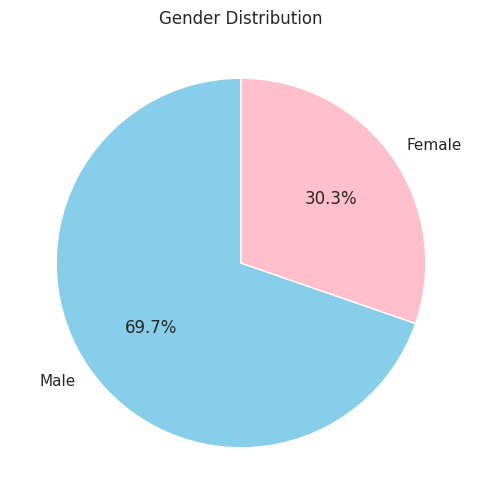

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Gender Distribution
plt.figure(figsize=(8, 6))
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'pink'], startangle=90)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

**Key Insights**:
Men represent nearly 70% of the customer base, while women make up approximately 30%.
Marketing campaigns should primarily target male audiences, or alternatively, look for opportunities to expand the currently smaller female market segment.

## $\color{purple}{\text{2.Age Distribution - A histogram with a kernel density estimate (KDE)}}$
 A histogram with a kernel density estimate (KDE) line showing the frequency of shoppers across various age groups.



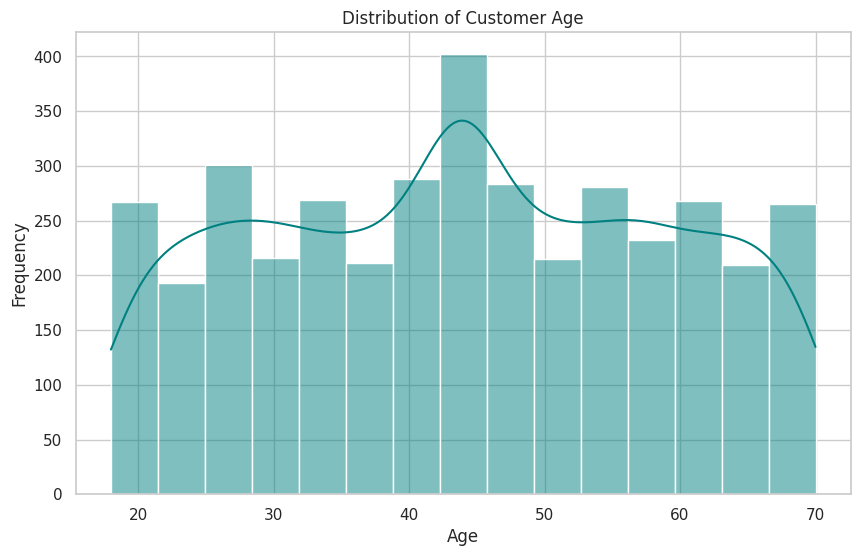

In [44]:
#Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=15, kde=True, color='teal')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Key Insights**: The average customer age is 44 years old.
Customers aged 30–45 are the most active segment (1,248 customers), followed by the 45–60 age group.
Product designs and marketing messages should resonate with Gen X and Millennials, who are the highest-spending age brackets in this dataset

## $\color{purple}{\text{3.Purchase Amount by Category - box plot}}$
A box plot comparing the distribution of spending (in USD) across different product categories like Clothing, Footwear, etc.



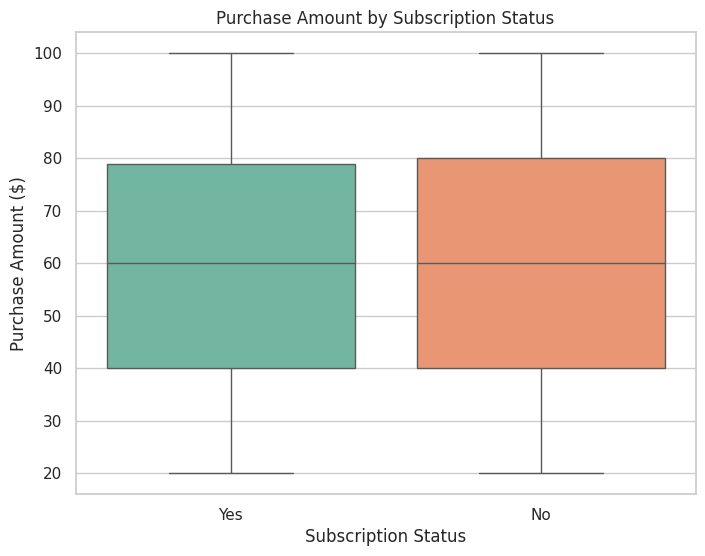

In [45]:
# Purchase Amount by Subscription Status (Box Plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='subscription_status', y='purchase_amount', data=df, palette='Set2', hue='subscription_status', legend=False)
plt.title('Purchase Amount by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Purchase Amount ($)')
plt.show()

**Key Insights**:Interestingly, there is almost no difference in the average purchase amount between subscribers (59.49) and non-subscribers (60.04).
While subscriptions may help with retention (loyalty), they are not currently driving "higher ticket" individual purchases. You might consider adding exclusive discounts or "member-only" high-value items to increase subscriber spending..

## $\color{purple}{\text{4.Payment Method Popularity-Horizontal Bar Chart}}$
Payment Method Popularity: A ranked list of the most used payment methods.



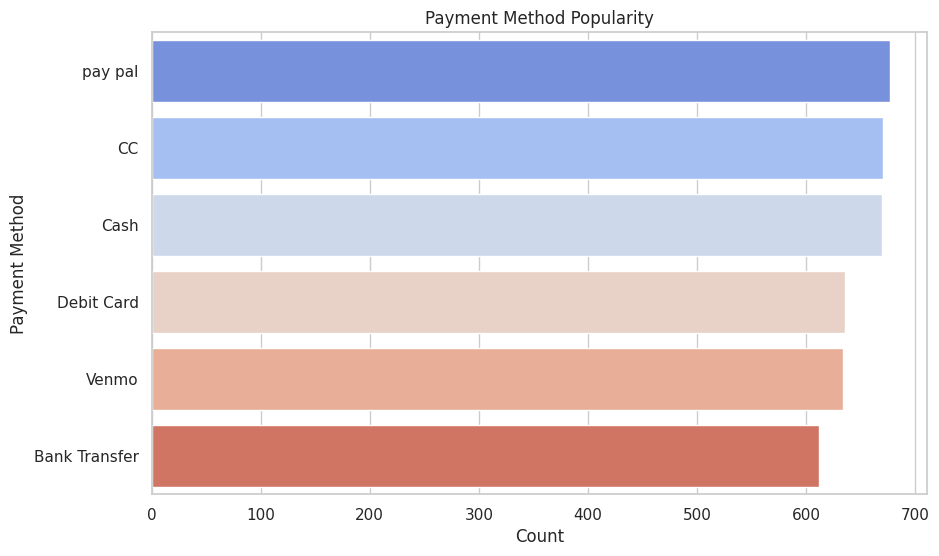

In [46]:
# Payment Method Usage (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))
payment_counts = df['payment_method'].value_counts().sort_values(ascending=False).reset_index()
sns.barplot(x='count', y='payment_method', data=payment_counts, palette='coolwarm', hue='payment_method', legend=False)
plt.title('Payment Method Popularity')
plt.xlabel('Count')
plt.ylabel('Payment Method')
plt.show()

 **Key Insights** :PayPal and Credit Cards are the most popular, but the usage is extremely balanced across all methods (Cash, Venmo, Debit, and Bank Transfer).
Customers appreciate payment flexibility. Ensure all digital wallets and transfer methods remain seamless as no single method dominates.

## $\color{purple}{\text{5.Sales Volume By Category - Donut Chart}}$
A donut chart identifying the most purchased categories.

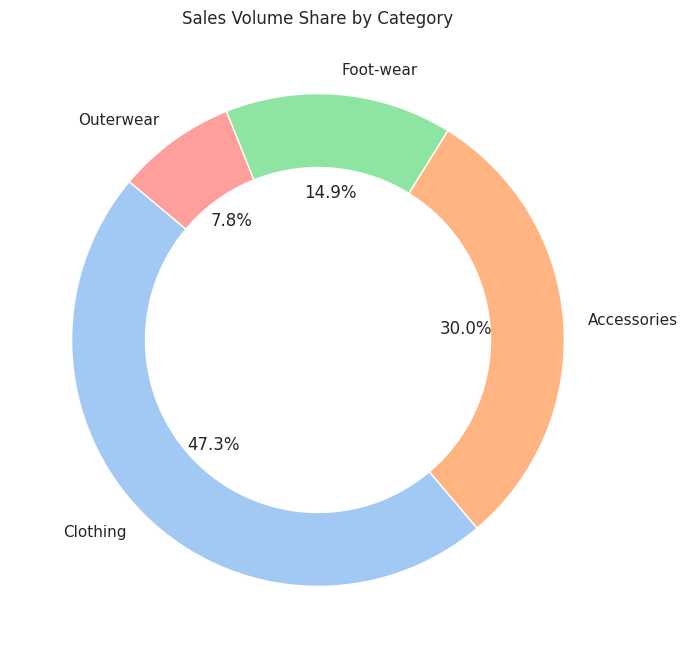

In [47]:
# Counting occurrences of each category
category_counts = df['category'].value_counts()

# Plotting
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
# Creating the "Donut" hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sales Volume Share by Category')
plt.show()

**Key Insights** : Clothing is by far the strongest category, accounting for 47.4% ($110,702) of the total revenue.
Accessories contribute 30% of sales, making it a critical secondary category.
Focus inventory and promotional budget on Clothing and Accessories as they drive nearly 80% of your total business.

## $\color{purple}{\text{6.Seasonal Trends - Bar Chart}}$
Seasonal Trends: A bar chart showing how total spending fluctuates across different seasons

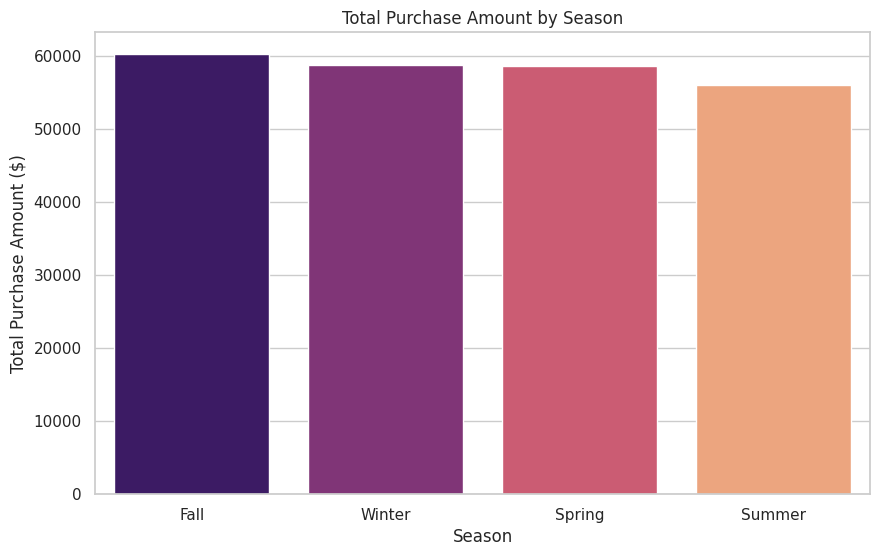

In [48]:
# 6. Seasonal Trends (Bar Chart)
plt.figure(figsize=(10, 6))
season_spending = df.groupby('season')['purchase_amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(x='season', y='purchase_amount', data=season_spending, palette='magma', hue='season', legend=False)
plt.title('Total Purchase Amount by Season')
plt.xlabel('Season')
plt.ylabel('Total Purchase Amount ($)')
plt.show()

**Key Insights**: Fall is the highest-grossing season (60,215) though the difference between seasons is relatively small.
Summer sees the lowest spending (55,972).
Prepare for a "Fall Surge" with new inventory. Consider running "Summer Sales" or "Mid-Year Clearances" to boost the lower spending seen in the summer months

## $\color{purple}{\text{7.Loyality vs. Satisfaction - Heatmap}}$
Loyalty vs. Satisfaction Heatmap: A matrix showing the count of customers across different loyalty and satisfaction tiers.

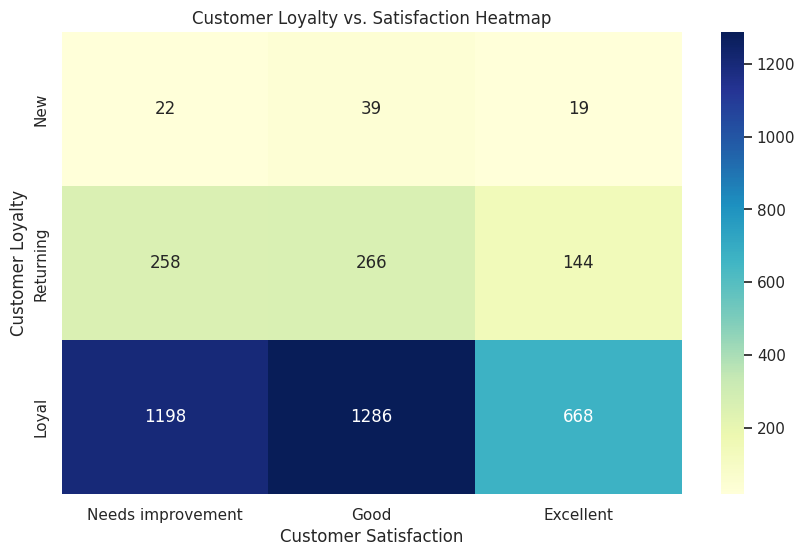

In [49]:
#7. Customer Satisfaction and Loyalty Matrix (Heatmap)
plt.figure(figsize=(10, 6))
loyalty_satisfaction = df.groupby(['customer_loyality', 'customer_satisfaction'], observed=False).size().unstack()
sns.heatmap(loyalty_satisfaction, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Customer Loyalty vs. Satisfaction Heatmap')
plt.xlabel('Customer Satisfaction')
plt.ylabel('Customer Loyalty')
plt.show()

**Key Insights** : Most "Loyal" customers rate their satisfaction as "Good" (1,286) or "Needs Improvement" (1,198). Only a smaller segment (668) rates it as "Excellent."
There is a "Loyalty Gap." Many customers stay loyal to the brand despite not being fully satisfied. Improving the customer experience (e.g., faster shipping or better support) could turn "Good" ratings into "Excellent," potentially increasing their spending frequency.

## $\color{purple}{\text{8.Distribution of purchase amount by category and gender - Violin Plot}}$


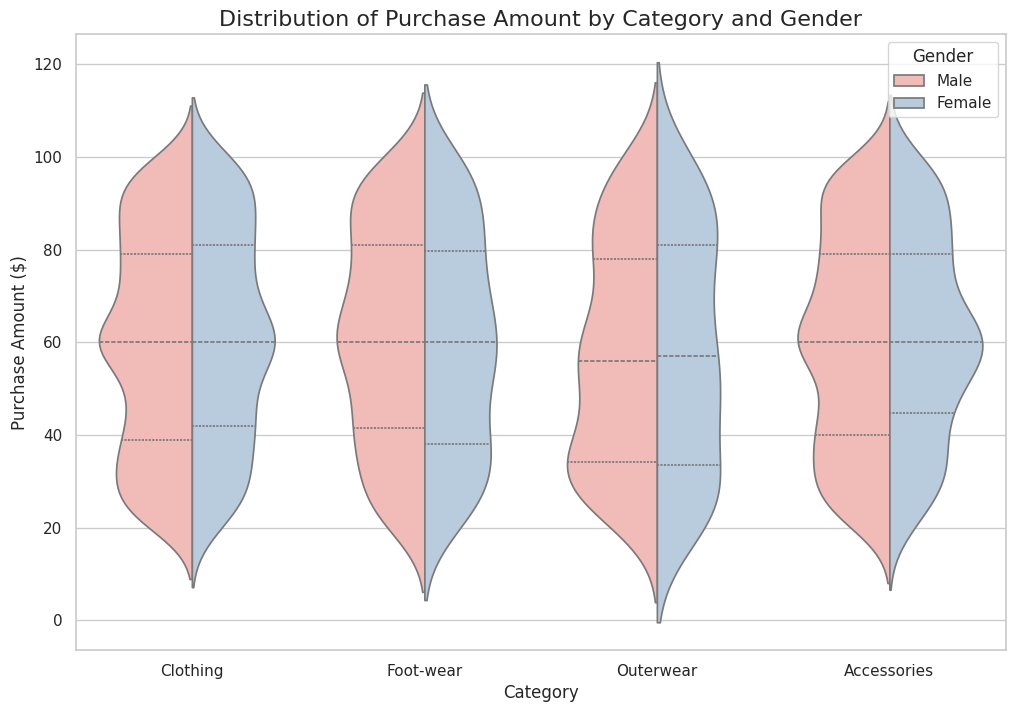

In [50]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a Violin Plot
# Visualizing 'purchase_amount' distribution across 'category' split by 'gender'
plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x='category', y='purchase_amount', hue='gender', split=True, palette='Pastel1', inner="quart")

plt.title('Distribution of Purchase Amount by Category and Gender', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Purchase Amount ($)', fontsize=12)
plt.legend(title='Gender', loc='upper right')

# Display the plot
plt.show()

**Key Insights** :The "width" of the violins is fairly uniform across all categories (Clothing, Footwear, Outerwear, Accessories). This suggests that the distribution of prices is consistent; you have a similar volume of low-cost, mid-range, and high-cost items across all departments.
By splitting the violins by gender, we can see that the internal quartiles (the dashed lines inside) are almost at the same level for both Men and Women. This confirms that gender does not significantly influence the amount spent per transaction in any specific category.

## $\color{purple}{\text{9.Interactive Location Insights - Plotly Bar Chart}}$


In [51]:
# Plotly Interactive Bar Chart: Spending by Location
# Insight: Allows you to hover over each state to see the exact total revenue.
location_spending = df.groupby('location')['purchase_amount'].sum().reset_index().sort_values(by='purchase_amount', ascending=False)

fig = px.bar(location_spending,
             x='location',
             y='purchase_amount',
             title='Total Spending by Location (Interactive)',
             color='purchase_amount',
             labels={'purchase_amount': 'Total Sales ($)', 'location': 'State'},
             template='plotly_white')

fig.show()

**Key Insights** : Illinois is an extreme outlier in your dataset with total spending of **17,400**, followed by Montana (5,359) and California (5,274).
Kansas and Hawaii have the lowest total spending.
Illinois is the powerhouse state.investigate if there was a specific marketing campaign, a local event, or a physical store presence there that caused this massive spike. This "Illinois Model" could potentially be replicated in other high-population states like California or New York to boost their performance

## $\color{purple}{\text{10.Correlation Heatmap of customer metrics}}$


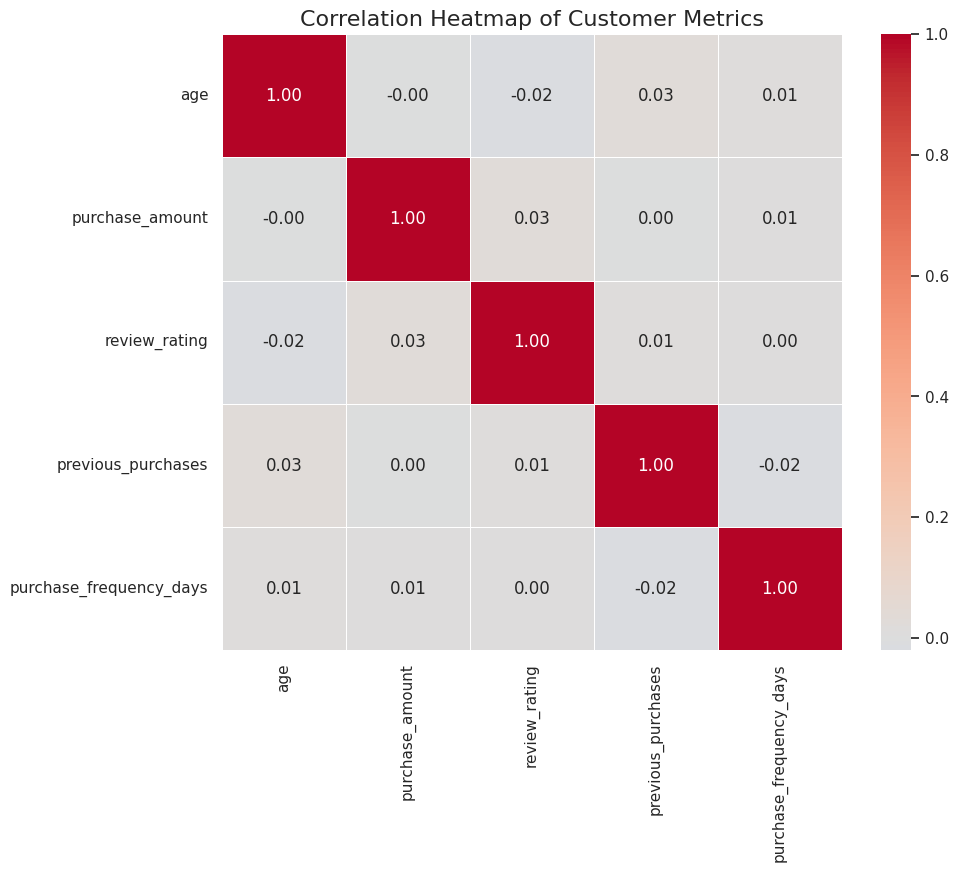

In [52]:
# Select numerical columns and exclude 'customer_id'
# This ensures we only analyze meaningful metrics like Age, Amount, and Rating
numerical_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['customer_id'], errors='ignore')

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,       # Shows the correlation numbers in the boxes
            cmap='coolwarm',  # Color scale (Red = Positive, Blue = Negative)
            fmt=".2f",        # Rounds numbers to 2 decimal places
            linewidths=0.5,   # Adds small gaps between the squares
            center=0)         # Ensures 0 is the neutral color

plt.title('Correlation Heatmap of Customer Metrics', fontsize=16)
plt.show()

**Key Insights** :
1) The correlation between Age and Purchase Amount is nearly zero ($-0.004$).What it means: There is no "richer" or "poorer" age group in your store. A 20-year-old and a 60-year-old have identical spending habits.
Your marketing should focus on style and product use rather than trying to target specific ages with "budget" or "premium" price points. Your products have universal financial appeal.
2) The correlation between Previous Purchases and Purchase Amount is effectively zero ($0.001$)."Loyal" customers (who have shopped 40+ times) are not buying more expensive items than first-time shoppers.
3) The correlation between Purchase Amount and Review Rating is very low ($0.026$).Usually, customers are harder to please when they pay more. However,in this data, a $100 item is rated as highly as a $20 item.It proves that high-priced items are meeting the increased expectations of the customers. You have a solid foundation to introduce even more premium, high-margin products without fear of bad reviews.
4) The correlation between Previous Purchases (History) and Purchase Frequency Days (Speed) is actually slightly negative ($-0.015$).What it means: You might assume that someone who has shopped 50 times visits more often than a new customer. The heatmap shows this isn't necessarily true. You have "Old Loyals" who visit infrequently but consistently over years, and "New Stars" who visit every week.Action: Don't treat all loyal customers the same. Segment them into "Active Loyals" (frequent) and "Passive Loyals" (infrequent) to tailor your email reminders.

# $\color{red}{\text{6.Final Documentation & Future Recommendation}}$

## **Project Documentation**

--> This project, titled 'Customer Shopping Behaviour Analysis', aimed to understand customer purchasing patterns and demographic trends within a retail setting. Utilizing a dataset of 3,950 consumer transaction records, the analysis covered aspects such as age, gender, product categories, and promotional impacts.

--> Initial data quality assessment identified missing values, duplicates, and inconsistencies, which were subsequently addressed through comprehensive cleaning, standardization, and imputation using median and mode values. Feature engineering was performed to create new segments like 'age_group', 'spending_tier', 'customer_loyalty', and 'customer_satisfaction', enhancing the dataset for deeper insights.

--> Exploratory Data Analysis (EDA) revealed key trends such as male customers generating higher revenue, the dominance of 'Clothing' and 'Accessories' categories, and 'Fall' as the highest-grossing season.

--> Visualizations, including pie charts, histograms, box plots, bar charts, heatmaps, and violin plots, illustrated gender distribution, age demographics, payment method popularity, seasonal trends, and the correlation between various customer metrics.

--> Overall, the project provides actionable insights for optimizing inventory, tailoring marketing strategies, and improving customer satisfaction and loyalty.

-->Analysis of the dataset revealed several critical insights:
 * Male customers are the primary revenue drivers, significantly outspending females.
 *'Clothing' and 'Accessories' are the top-performing product categories, with 'Fall' showing the highest sales volume.
 * Discounts are highly effective for specific items like hats and sneakers, indicating price-sensitive purchasing.
 * Interestingly, subscription status has little impact on average purchase amounts."Free Shipping" is the primary driver for completing a sale, highlighting a high sensitivity to added costs at the final stage of the journey
 * The most common shopping frequency is "Every 3 Months," representing nearly 600 core customers.Many customers are loyal, there's a 'satisfaction gap' that could be addressed to enhance their experience.
 * Overall, there's no strong correlation between age, purchase amount, or review ratings, suggesting broad product appeal across demographics rather than age-specific spending habits.

### **Future Recommendations**

1.  **Replicate the 'Illinois Model'**: Investigate the factors contributing to Illinois's significantly higher revenue (e.g., marketing campaigns, specific product lines, local partnerships). If replicable, apply these strategies to other high-population states or underperforming regions to boost sales.
2.  **Gender-Specific Marketing Campaigns**: Given that male customers contribute significantly more revenue, refine marketing strategies to further engage this demographic. Simultaneously, explore targeted campaigns and product offerings to expand the female customer base and increase their spending.
3.  **Enhance Subscriber Value**: Since subscribers' average spend is similar to non-subscribers, introduce exclusive benefits for subscribers such as members-only discounts on high-value items, early access to new collections, or free premium shipping to incentivize higher individual purchases.
4.  **Address the 'Loyalty Gap'**: Focus on improving the overall customer experience for 'Loyal' customers, especially those who rate their satisfaction as 'Good' or 'Needs Improvement'. Initiatives could include personalized recommendations, improved customer service, or special rewards for consistently loyal shoppers to convert 'Good' experiences into 'Excellent' ones.
5.  **Seasonal and Category Optimization**: Capitalize on the strong performance of 'Clothing' and 'Accessories' by ensuring robust inventory and strategic promotions for these categories. Leverage 'Fall' as the highest-grossing season for major product launches and marketing pushes, while implementing attractive sales or unique offerings during 'Summer' to mitigate lower spending.
6.  **Leverage Price Elasticity**: Continue to use discounts strategically for price-elastic items like hats and sneakers to drive sales volume. Consider bundling these items or using them as loss leaders to encourage purchases of higher-margin products.